In [31]:
import re
import numpy as np
import pandas as pd
import csv
import seaborn as sns
import matplotlib.pyplot as plt
import os
import itertools
import math
from Bio.SeqIO.FastaIO import FastaIterator
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import AutoMinorLocator
from scipy.stats import iqr

In [ ]:
"""
Search patterns for perfect and degenerate Tel repeats

"""

# patternG = "TTAGGG"
# patternC = "CCCTAA"

patternG = "T{1,2}A{0,1}G{3,5}|T{1,2}\D{1}A{1}G{3,5}|T{2}A{1}G{2}"
patternC = "C{3,5}T{0,1}A{1,2}|C{3,5}T{1}\D{1}A{1,2}|C{2}T{1}A{2}"

patternG_obj = re.compile(patternG)
patternC_obj = re.compile(patternC)

In [ ]:
filename = '240404_T2Tv2_genome_ncbi_dataset/ncbi_dataset/data/GCF_009914755.1/GCF_009914755.1_T2T-CHM13v2.0_genomic.fna'

In [ ]:
output_file = 'FuzzyTel_T2T-CHM13v2.0_genomic_loops_hist.pdf'

In [6]:
#Parsing fasta 
def fasta_reader(infile):
    with open(infile) as handle:
        for record in FastaIterator(handle):
            yield record

In [ ]:
def save_image(file, fig_list):

    pdf = PdfPages(file)

    for fig in fig_list: 
        fig.savefig(pdf, format='pdf') 
          
    pdf.close()  

In [8]:
def search_functionGC(myseq, pattern):
    ind_spans = [match.span() for match in re.finditer(pattern, myseq)]

    ind_start=[span[0] for span in ind_spans]
    ind_end=[span[1] for span in ind_spans]

    spans_length = np.subtract(ind_end, ind_start)
    if len(spans_length) > 0:
        spans_median = np.median(spans_length)
    else:
        spans_median = 0
    
    return ind_spans, ind_start, ind_end, spans_median

In [ ]:
def loop_function(myseq, start, end):
    """
    Determinez the loop lengths between repeats
    
    """

    ind_start = np.array(start)
    ind_end = np.array(end)
    sequence_length = len(myseq)

    if len(ind_start)>0:
        loop_list = np.subtract(ind_start[1:], ind_end[:-1])
        start_loop = ind_start[0]
        end_loop = sequence_length -ind_end[-1]
        
        loop_list_left_tail = np.insert(loop_list, 0, start_loop)
        loop_list_arr = np.append(loop_list_left_tail, end_loop)

    loop_median = np.median(loop_list_arr) 
    loop_std = np.std(loop_list_arr)
        

    return loop_list_arr, loop_median, loop_std


In [10]:
def bin_range(loop_list_arrG, loop_list_arrC):
    """
    Calculates the optimal bin range for a given list of coordinates
    for complementary strands, presented as subplots. Thus, that bins are equal for the subplots.

    Args:
    -----
    loop_list_arrG, loop_list_arrC : `array <int>`
        Numpy 1-d array with genomic coordinates
    Returns:
    --------
    bins : `array <int>`
        The list of bins, ready for plotting
    """

    maxG = np.max(loop_list_arrG)
    lenG = len(loop_list_arrG)
    sdevG = np.std(loop_list_arrG)
    percent99G = np.percentile(loop_list_arrG, 99)   
    maxC = np.max(loop_list_arrC)
    lenC = len(loop_list_arrC)
    sdevC = np.std(loop_list_arrC)
    percent99C = np.percentile(loop_list_arrC, 99)

    maxGC = max(maxG, maxC)
    maxdev = max(sdevG, sdevC)
    maxpercent = max(percent99G, percent99C)
    lenGC = max(lenG, lenC)   
    if maxdev+maxpercent >= maxGC:
        maxpercent_adj = maxdev+maxpercent
    else:
        maxpercent_adj = maxpercent
    
    if maxdev+maxpercent == 0:
        maxpercent_adj = lenGC

    if lenGC <= 4:
        max_bin_count = 10
    else:
        max_bin_count = min(100, lenGC)

    step=math.ceil(maxpercent_adj/max_bin_count)
    maxpercent_plus = maxpercent_adj+step
    bins_range = np.arange(0,maxpercent_plus,step)
    bins_range_plus = np.append(bins_range, bins_range[-1]+step)

    return bins_range_plus

In [58]:
def image_hist_loops_multifasta(loop_list_arrG, loop_list_arrC, description, loops_hist, loop_medianG, loop_medianC):

    def fig2():
        patternG_title = 'FuzzyTel Clusters, G-orientation'
        patternC_title = 'FuzzyTel Clusters, C-orientation'
        # patternG_title = 'TTAGGG'
        # patternC_title = 'CCCTAA'
        maxG = np.max(loop_list_arrG)
        maxC = np.max(loop_list_arrC)
        meanG = np.mean(loop_list_arrG)
        meanC = np.mean(loop_list_arrC)
        sdevG = np.std(loop_list_arrG)
        sdevC = np.std(loop_list_arrC)
        percentile75G = np.percentile(loop_list_arrG, 75)
        percentile75C = np.percentile(loop_list_arrC, 75)
        percentile25G = np.percentile(loop_list_arrG, 25)
        percentile25C = np.percentile(loop_list_arrC, 25)
        iqrG = iqr(loop_list_arrG)
        iqrC = iqr(loop_list_arrC)
        
        bins1=bin_range(loop_list_arrG, loop_list_arrC)
        maxbin = bins1[-1]
        binGС = int(bins1[1])

        fig2, (ax1, ax2) = plt.subplots(2,1, sharex=True)
        # ax1.set_title(f'{description} \n\n pattern "{patternG}"', fontsize=6)
        ax1.set_title(f'pattern {patternG_title}', fontsize=12)
        ax1.hist([np.clip(loop_list_arrG, bins1[0], bins1[-1])], bins=bins1, label='LoopG', color='royalblue')
        ax1.legend(loc=1)
        
        ax1.set_xlim(0, maxbin)
        ax1.set_ylabel("Number", fontsize=14)
        min_ylim, max_ylim = ax1.set_ylim()
        ax1.axvline(loop_medianG, color='k', linestyle='dashed', linewidth=1)
        ax1.axvline(percentile25G, color='c', linestyle='dotted', linewidth=1)
        ax1.axvline(percentile75G, color='c', linestyle='dotted', linewidth=1)
        # ax1.text(percentile75G*1.1, max_ylim*0.7, 'Q3: {:.2f}'.format(percentile75G))
        ax1.text(loop_medianG*1.1, max_ylim*0.8, 'Median:\n {:.2f}'.format(loop_medianG))
        ax1.text(maxbin*0.75, max_ylim*0.7, 'Mean: {:.2f}'.format(meanG))
        # ax1.text(maxbin*0.75, max_ylim*0.6, 'Sdev: {:.2f}'.format(sdevG))
        ax1.text(maxbin*0.75, max_ylim*0.6, 'IQR: {:.2f}'.format(iqrG))
        ax1.text(maxbin*0.75, max_ylim*0.5, 'Max: {:d}'.format(maxG))
        ax1.text(maxbin*0.75, max_ylim*0.4, 'Bin: {:d}'.format(binGС))
        if maxG >=bins1[-2]:
            ax1.axvline(bins1[-2], color='r', linestyle='dashed', linewidth=1)
            ax1.text(maxbin*0.75, max_ylim*0.3, 'OL: \u2265 {:d}'.format(math.floor(bins1[-2])), color='r')
        
        # ax2.set_title(f'pattern "{patternC}"', fontsize=6)
        ax2.set_title(f'pattern {patternC_title}', fontsize=12)
        ax2.hist([np.clip(loop_list_arrC, bins1[0], bins1[-1])], bins=bins1, label='LoopC', color='seagreen')
        ax2.legend(loc=1)
        plt.xlabel("Loop length", fontsize=14)
        ax2.set_xlim(0, maxbin)
        ax2.set_ylabel("Number", fontsize=14)
        min_ylim, max_ylim = ax2.set_ylim()
        ax2.axvline(loop_medianC, color='k', linestyle='dashed', linewidth=1)
        ax2.axvline(percentile25C, color='c', linestyle='dotted', linewidth=1)
        ax2.axvline(percentile75C, color='c', linestyle='dotted', linewidth=1)
        # ax2.text(percentile75C*1.1, max_ylim*0.7, 'Q3: {:.2f}'.format(percentile75C))
        ax2.text(loop_medianC*1.1, max_ylim*0.8, 'Median:\n {:.2f}'.format(loop_medianC))
        ax2.text(maxbin*0.75, max_ylim*0.7, 'Mean: {:.2f}'.format(meanC))
        # ax2.text(maxbin*0.75, max_ylim*0.6, 'Sdev: {:.2f}'.format(sdevC))
        ax2.text(maxbin*0.75, max_ylim*0.6, 'IQR: {:.2f}'.format(iqrC))
        ax2.text(maxbin*0.75, max_ylim*0.5, 'Max: {:d}'.format(maxC))
        ax2.text(maxbin*0.75, max_ylim*0.4, 'Bin: {:d}'.format(binGС))
        if maxC >=bins1[-2]:
            ax2.axvline(bins1[-2], color='r', linestyle='dashed', linewidth=1)
            ax2.text(maxbin*0.75, max_ylim*0.3, 'OL: \u2265 {:d}'.format(math.floor(bins1[-2])), color='r')
        ax1.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax2.xaxis.set_minor_locator(AutoMinorLocator(5)) 
        ax1.yaxis.set_minor_locator(AutoMinorLocator(4))
        ax2.yaxis.set_minor_locator(AutoMinorLocator(4)) 
        fig2.suptitle('Loop length distribution')
        fig2.tight_layout()
        print('bins1', bins1)

        return fig2
    
    figure2 = fig2()
    loops_hist.append(figure2)
    return loops_hist


In [ ]:
def complete_prediction_multifasta(filename, patternG_obj, patternC_obj):    
    loops_hist = []

    loopsG_arr = []
    loopsC_arr = []
    loopsG_median = []
    loopsC_median = []


    pdf_loops_hist = output_file
    

    for entry in fasta_reader(filename):
        seqname = entry.id
        seq = entry.seq
        description = entry.description
        print(description)
        seq = str(seq).replace(' ', '').upper()
        resultG = search_functionGC(seq, patternG_obj)
        resultC = search_functionGC(seq, patternC_obj)

        indG = resultG[0]
        indC = resultC[0]
        ind_startG = resultG[1]
        ind_endG = resultG[2]
        ind_startC = resultC[1]
        ind_endC = resultC[2]
        spans_medianG = resultG[3]
        spans_medianC = resultC[3]
        
        loop_list_arrG = loop_function(seq, ind_startG, ind_endG)
        loop_list_arrC = loop_function(seq, ind_startC, ind_endC)
    
        loopsG_arr.append(loop_list_arrG[0])
        loopsC_arr.append(loop_list_arrC[0])
        loopsG_median.append(loop_list_arrG[1])
        loopsC_median.append(loop_list_arrC[1])
        
    
    combined_arrayG = np.concatenate(loopsG_arr)
    combined_arrayC = np.concatenate(loopsC_arr)
    combined_medianG = np.median(combined_arrayG)
    combined_medianC = np.median(combined_arrayC)
    median_across_chromosomesG = np.median(loopsG_median)
    median_across_chromosomesC = np.median(loopsC_median)
    std_across_chromosomesG = np.std(loopsG_median)
    std_across_chromosomesC = np.std(loopsC_median)
    
    whole_description = 'T2TV2.0 genome'
    print('loopsG_median', loopsG_median)
    print('loopsC_median', loopsC_median)
    print('median_acrossG', median_across_chromosomesG)
    print('median_acrossC', median_across_chromosomesC)
    print('std_acrossG', std_across_chromosomesG)
    print('std_acrossC', std_across_chromosomesC)

    figure2 = image_hist_loops_multifasta(combined_arrayG, combined_arrayC, whole_description, loops_hist, combined_medianG, combined_medianC)


    save_image(pdf_loops_hist, figure2)

NC_060925.1 Homo sapiens isolate CHM13 chromosome 1, alternate assembly T2T-CHM13v2.0
NC_060926.1 Homo sapiens isolate CHM13 chromosome 2, alternate assembly T2T-CHM13v2.0
NC_060927.1 Homo sapiens isolate CHM13 chromosome 3, alternate assembly T2T-CHM13v2.0
NC_060928.1 Homo sapiens isolate CHM13 chromosome 4, alternate assembly T2T-CHM13v2.0
NC_060929.1 Homo sapiens isolate CHM13 chromosome 5, alternate assembly T2T-CHM13v2.0
NC_060930.1 Homo sapiens isolate CHM13 chromosome 6, alternate assembly T2T-CHM13v2.0
NC_060931.1 Homo sapiens isolate CHM13 chromosome 7, alternate assembly T2T-CHM13v2.0
NC_060932.1 Homo sapiens isolate CHM13 chromosome 8, alternate assembly T2T-CHM13v2.0
NC_060933.1 Homo sapiens isolate CHM13 chromosome 9, alternate assembly T2T-CHM13v2.0
NC_060934.1 Homo sapiens isolate CHM13 chromosome 10, alternate assembly T2T-CHM13v2.0
NC_060935.1 Homo sapiens isolate CHM13 chromosome 11, alternate assembly T2T-CHM13v2.0
NC_060936.1 Homo sapiens isolate CHM13 chromosome 12

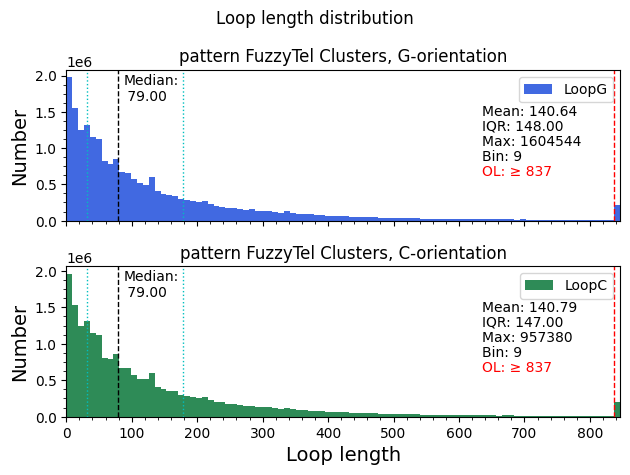

In [59]:
prediction = complete_prediction_multifasta(filename, patternG_obj, patternC_obj)